In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
calib_data = {
    'Tap1': {'v': [2.700, 3.100, 3.500, 3.900, 4.200],
             'raw': [2192, 2542, 2865, 3265, 3595]},
    'Tap2': {'v': [5.400, 6.200, 7.000, 7.800, 8.400],
             'raw': [2080, 2396, 2716, 3064, 3362]},
    'Tap3': {'v': [8.100, 9.300, 10.500, 11.700, 12.600],
             'raw': [2134, 2462, 2805, 3162, 3484]},
}

In [3]:
def fit_tap(v, raw, name):
    v = np.array(v)
    raw = np.array(raw)

    lin_coef = np.polyfit(raw, v, 1)
    lin_err = np.abs(v - np.polyval(lin_coef, raw))

    quad_coef = np.polyfit(raw, v, 2)
    quad_err = np.abs(v - np.polyval(quad_coef, raw))

    use_quad = quad_err.max() < lin_err.max()
    coef = quad_coef if use_quad else lin_coef
    err = quad_err if use_quad else lin_err

    print(f"--- {name} ---")
    print(f"Linear max error:    {lin_err.max()*1000:.1f} mV")
    print(f"Quadratic max error: {quad_err.max()*1000:.1f} mV")
    print(f"-> Using {'QUADRATIC' if use_quad else 'LINEAR'}")
    print(f"Per-point errors (mV): {np.round(err*1000, 1)}")
    if err.max() * 1000 > 10:
        print(f"*** Still above 10mV target -- see diagnostics below ***")
    print()
    return coef, use_quad, err

In [4]:
results = {}
for name, d in calib_data.items():
    coef, use_quad, err = fit_tap(d['v'], d['raw'], name)
    results[name] = {'coef': coef, 'use_quad': use_quad, 'err': err}

--- Tap1 ---
Linear max error:    48.8 mV
Quadratic max error: 20.9 mV
-> Using QUADRATIC
Per-point errors (mV): [ 7.9 20.9 14.   2.4  3.3]
*** Still above 10mV target -- see diagnostics below ***

--- Tap2 ---
Linear max error:    61.5 mV
Quadratic max error: 16.8 mV
-> Using QUADRATIC
Per-point errors (mV): [ 8.2 16.8  2.  14.7  8.1]
*** Still above 10mV target -- see diagnostics below ***

--- Tap3 ---
Linear max error:    102.3 mV
Quadratic max error: 36.5 mV
-> Using QUADRATIC
Per-point errors (mV): [11.3 17.2 13.8 36.5 16.7]
*** Still above 10mV target -- see diagnostics below ***



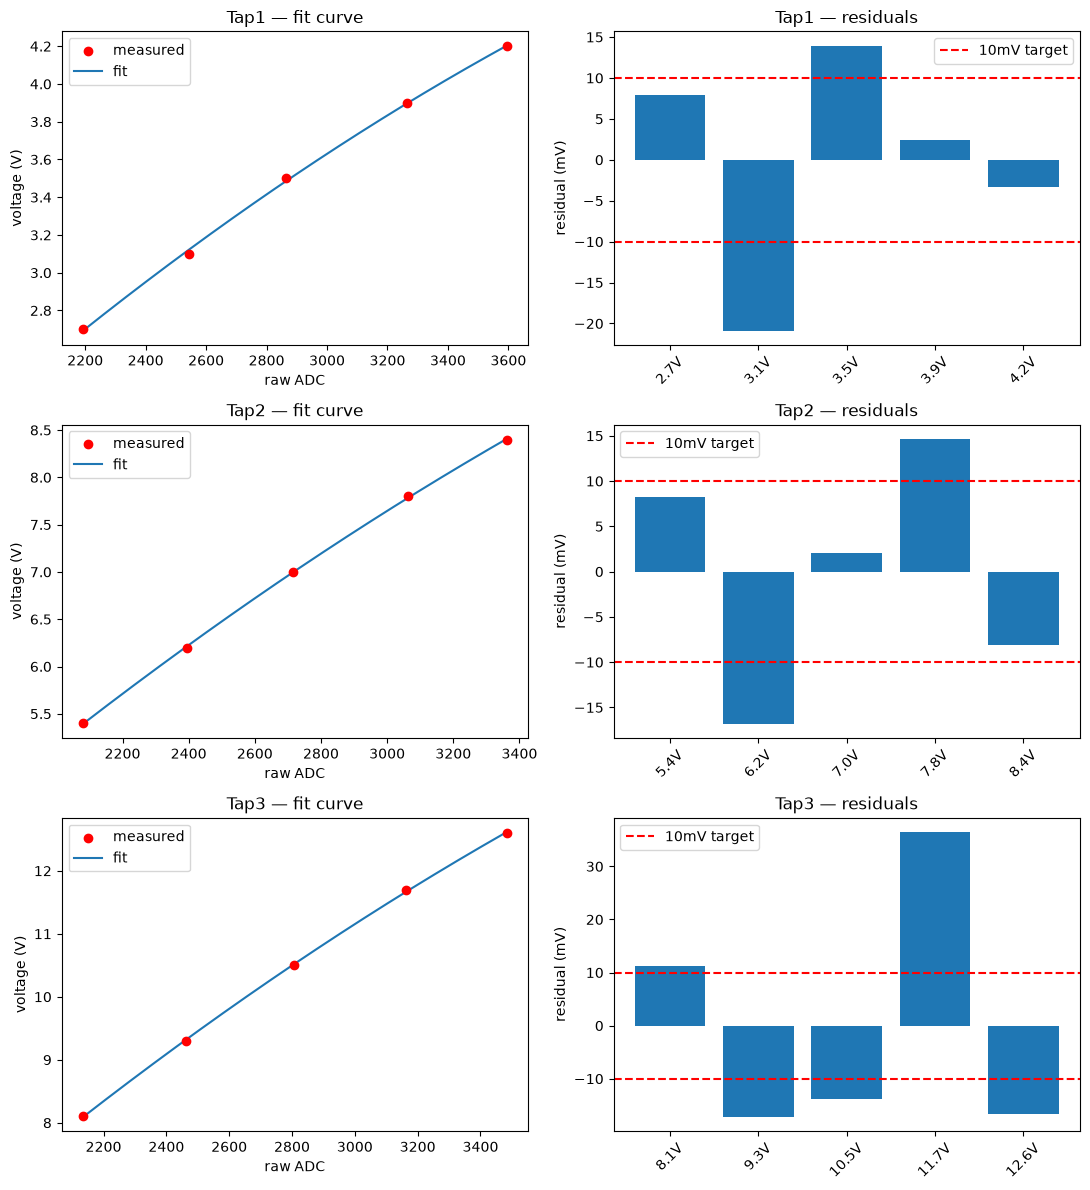

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(11, 12))
for i, (name, d) in enumerate(calib_data.items()):
    v, raw = np.array(d['v']), np.array(d['raw'])
    coef = results[name]['coef']
    raw_fine = np.linspace(raw.min(), raw.max(), 200)
    v_fit = np.polyval(coef, raw_fine)

    axes[i,0].scatter(raw, v, color='red', zorder=3, label='measured')
    axes[i,0].plot(raw_fine, v_fit, label='fit')
    axes[i,0].set_xlabel('raw ADC'); axes[i,0].set_ylabel('voltage (V)')
    axes[i,0].set_title(f'{name} — fit curve'); axes[i,0].legend()

    resid = (v - np.polyval(coef, raw)) * 1000
    axes[i,1].bar(range(len(v)), resid)
    axes[i,1].axhline(10, color='r', linestyle='--', label='10mV target')
    axes[i,1].axhline(-10, color='r', linestyle='--')
    axes[i,1].set_xticks(range(len(v)))
    axes[i,1].set_xticklabels([f'{x}V' for x in v], rotation=45)
    axes[i,1].set_ylabel('residual (mV)')
    axes[i,1].set_title(f'{name} — residuals'); axes[i,1].legend()
plt.tight_layout()
plt.show()

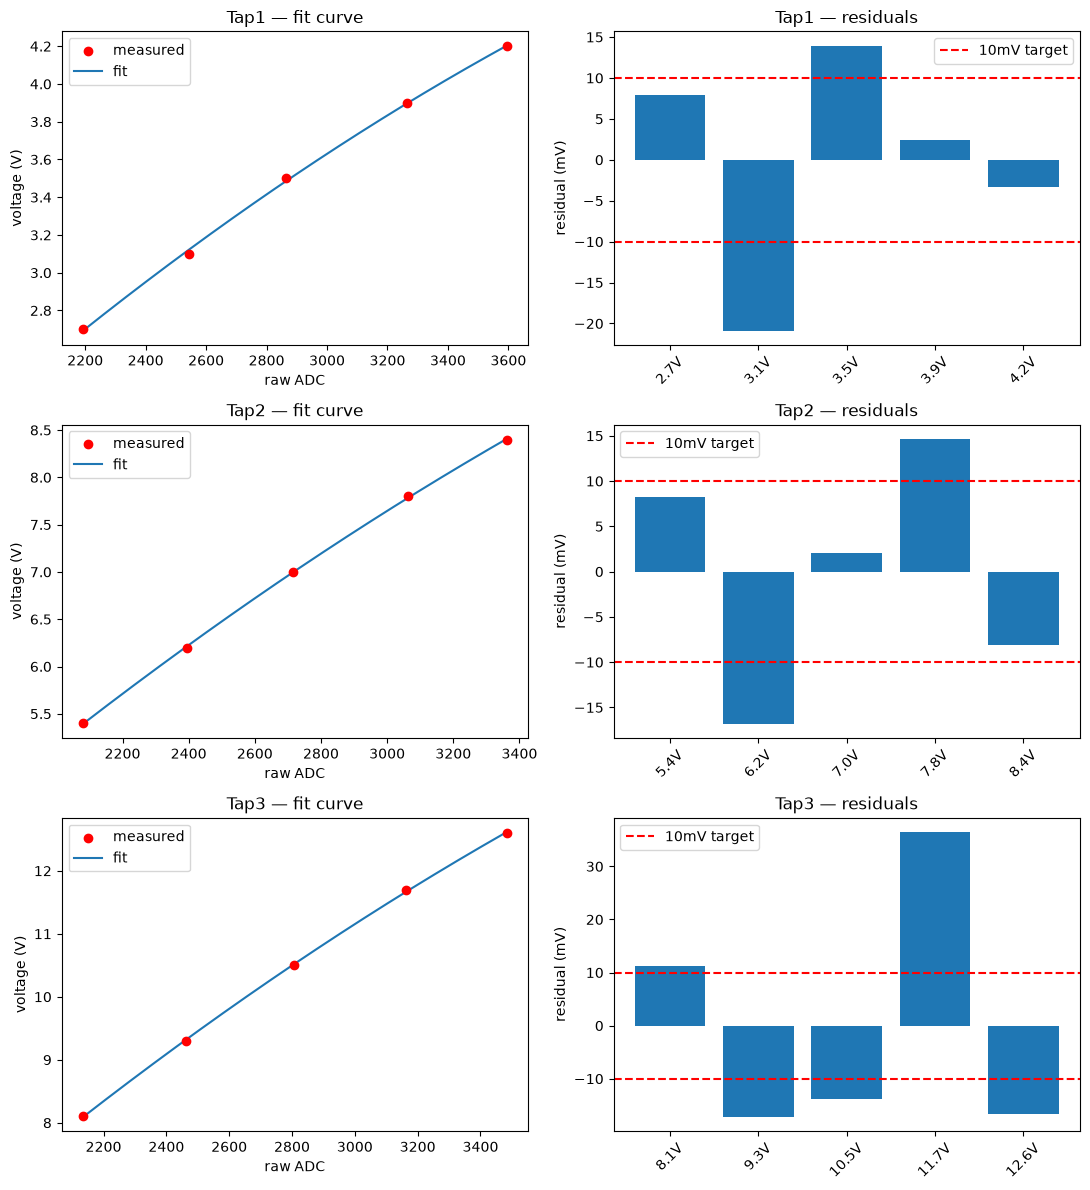

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(11, 12))
for i, (name, d) in enumerate(calib_data.items()):
    v, raw = np.array(d['v']), np.array(d['raw'])
    coef = results[name]['coef']
    raw_fine = np.linspace(raw.min(), raw.max(), 200)
    v_fit = np.polyval(coef, raw_fine)

    axes[i,0].scatter(raw, v, color='red', zorder=3, label='measured')
    axes[i,0].plot(raw_fine, v_fit, label='fit')
    axes[i,0].set_xlabel('raw ADC'); axes[i,0].set_ylabel('voltage (V)')
    axes[i,0].set_title(f'{name} — fit curve'); axes[i,0].legend()

    resid = (v - np.polyval(coef, raw)) * 1000
    axes[i,1].bar(range(len(v)), resid)
    axes[i,1].axhline(10, color='r', linestyle='--', label='10mV target')
    axes[i,1].axhline(-10, color='r', linestyle='--')
    axes[i,1].set_xticks(range(len(v)))
    axes[i,1].set_xticklabels([f'{x}V' for x in v], rotation=45)
    axes[i,1].set_ylabel('residual (mV)')
    axes[i,1].set_title(f'{name} — residuals'); axes[i,1].legend()
plt.tight_layout()
plt.show()

In [7]:
def leave_one_out(v, raw, name):
    v, raw = np.array(v), np.array(raw)
    print(f"--- {name} leave-one-out ---")
    for i in range(len(v)):
        mask = np.ones(len(v), dtype=bool)
        mask[i] = False
        if mask.sum() < 3:
            continue
        coef = np.polyfit(raw[mask], v[mask], 2)
        err_excluded = abs(v[i] - np.polyval(coef, raw[i])) * 1000
        print(f"  Excluding {v[i]}V -> residual on that point = {err_excluded:.1f} mV")
    print()

for name, d in calib_data.items():
    leave_one_out(d['v'], d['raw'], name)

--- Tap1 leave-one-out ---
  Excluding 2.7V -> residual on that point = 71.3 mV
  Excluding 3.1V -> residual on that point = 33.2 mV
  Excluding 3.5V -> residual on that point = 27.8 mV
  Excluding 3.9V -> residual on that point = 3.8 mV
  Excluding 4.2V -> residual on that point = 25.0 mV

--- Tap2 leave-one-out ---
  Excluding 5.4V -> residual on that point = 71.5 mV
  Excluding 6.2V -> residual on that point = 26.9 mV
  Excluding 7.0V -> residual on that point = 4.1 mV
  Excluding 7.8V -> residual on that point = 23.3 mV
  Excluding 8.4V -> residual on that point = 61.0 mV

--- Tap3 leave-one-out ---
  Excluding 8.1V -> residual on that point = 94.4 mV
  Excluding 9.3V -> residual on that point = 27.5 mV
  Excluding 10.5V -> residual on that point = 27.7 mV
  Excluding 11.7V -> residual on that point = 58.1 mV
  Excluding 12.6V -> residual on that point = 132.9 mV



In [8]:
print("=" * 55)
print("Paste into ESP32 firmware:")
print("=" * 55)
for name in ['Tap1', 'Tap2', 'Tap3']:
    coef = results[name]['coef']
    use_quad = results[name]['use_quad']
    max_err = results[name]['err'].max() * 1000
    if use_quad:
        print(f"// {name}: max_error={max_err:.1f}mV")
        print(f"const float {name.lower()}_a = {coef[0]:.6e}f;")
        print(f"const float {name.lower()}_b = {coef[1]:.8f}f;")
        print(f"const float {name.lower()}_c = {coef[2]:.6f}f;")
    else:
        print(f"// {name}: max_error={max_err:.1f}mV (linear)")
        print(f"const float {name.lower()}_slope  = {coef[0]:.8f}f;")
        print(f"const float {name.lower()}_offset = {coef[1]:.6f}f;")

Paste into ESP32 firmware:
// Tap1: max_error=20.9mV
const float tap1_a = -1.404856e-07f;
const float tap1_b = 0.00189009f;
const float tap1_c = -0.775924f;
// Tap2: max_error=16.8mV
const float tap2_a = -2.672302e-07f;
const float tap2_b = 0.00380713f;
const float tap2_c = -1.370929f;
// Tap3: max_error=36.5mV
const float tap3_a = -3.830651e-07f;
const float tap3_b = 0.00550616f;
const float tap3_c = -1.916985f;
